# Learning from the first trading days of an IPO
## A Bayesian study of persistence, trading intensity and remaining day-60 returns

When a company starts trading for the first time after its IPO, investors know relatively little about how the market will price the stock. After the trading begins, however, some elements start becoming observable: the price dynamics, the trading volume and the volatility of the stock. 

> Can those first trading days tech investors something about what is likely to happen over the rest of the IPO's first 60 days?

Instead of using difficult to obtain data such as exact free float or specific lock-up structure, the project looks at metrics such as early price performance, trading activity, IPO size, market returns and volatility. The analysis performed adopts a Bayesian approach to answer the question, starting from what historical IPOs suggest and progressively updating the probability distribution as new information from the IPO analiysed becomes available. The key goal is, effectively, testing whether early strength tends to persist or reverse, whether intense trading adds useful information beyond what is incorporated in the price and whether volatility helps predict how uncertain the remaining price will be. All the models are carefully tested on later IPOs, accounting for missing historical price data, in order to avoid survivorship bias.

## Notebook roadmap

1. Define the question and the information boundary
2. Audit 903 usable IPOs, including 60 at or above $1bn
3. Separate the initial IPO move from aftermarket returns
4. Explain and compare M0–M3 with training-only priors and scaling
5. Freeze selection, assess later IPOs and demonstrate sequential prediction
6. Study normalization, missing outcomes and implications for mega-IPOs

In [1]:
from pathlib import Path
import sys, json, platform
def _find_release_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'tape_data.py').exists() and (candidate / 'models' / 'tape_selection.json').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from the standalone release folder (or one of its subfolders).')
ROOT = _find_release_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc 
from IPython.display import display
from src.tape_data import load_prepared, cutoff_data, proxy_validation, OUT
from src import tape_plots as plots
from src.tape_models import load_trace
from src.tape_api import load_frozen_population, build_new_ipo_prior, update_ipo_distribution
plots.style()
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
audit, panel = load_prepared()
selection = json.loads((ROOT / 'models/tape_selection.json').read_text())
registry = json.loads((ROOT / 'models/tape_registry.json').read_text())
predictions = pd.read_csv(OUT / 'tape_predictions.csv')
scores = pd.read_csv(OUT / 'tape_scores.csv')
coefficients = pd.read_csv(OUT / 'tape_coefficients.csv')
print('Python', platform.python_version(), '| IPOs', audit.usable.sum(), '| snapshot 2026-09-07')

Python 3.13.9 | IPOs 903 | snapshot 2026-09-07


# 1. Research motivation and question

## 1.1 From structural IPO characteristics to observable early trading

A more complete analysis would aim to study whether post-IPO returns could be predicted from structural characteristics such as initial free float and lock-up provisions. These variables are economically relevant because they may affect the amount of stocks available for trading after an IPO. However, the public data collected in the feasibility analysis were not sufficient to estimate such relationships reliably: only 11 IPOs had the main structural variables jointly available, and the usable lock-up observations showed no variation in duration. A regression based on these data would be weakly identified and would rely excessively on modelling assumptions or Bayesian priors rather than on information contained in the data.

For this reason, the project is designed around variables that can be observed consistently after an IPO begins trading, such as price performance, trading activity, IPO size and realized volatility. The project asks whether the observable early trading record contains useful information about the subsequent price-discovery process.

## 1.2 Main research question

For IPO $i$, suppose that trading has been observed through day $t$. The main research question is:

> **Does information contained in the first trading days help predict whether the IPO will outperform or underperform the market over the remainder of its first 60 trading days?**

The outcome is defined as the remaining benchmark-adjusted log return,


$$Y_{i,t}
=
\sum_{s=t+1}^{60}
\left(r_{i,s}-r_{b,s}\right),
$$

where $r_{i,s}$ is the IPO's log return and $r_{b,s}$ is the return of the chosen market benchmark on the same trading day.

For example, when $t=10$,

$$
Y_{i,10}
$$

measures the IPO's market-adjusted performance from trading day 11 through trading day 60. A positive value means that the IPO subsequently outperformed the benchmark, while a negative value means that it underperformed.

The object estimated by the project is therefore

$$
p\!\left(
Y_{i,t}
\mid
\mathcal I_{i,t},
D_{\mathrm{historical}}
\right),
$$

where $D_{\mathrm{historical}}$ represents the historical IPO sample and $\mathcal I_{i,t}$ contains only the information available for IPO $i$ through trading day $t$.

The first question is whether early market-adjusted price strength tends to **persist** or **reverse**. The analysis then asks whether two additional pieces of information improve the predictive distribution:

1. **Trading intensity:** how large cumulative dollar trading has been relative to the gross value of the IPO
2. **Realized volatility:** how large the IPO's price fluctuations have been during its first trading days

The goal is not to obtain one precise future return estimate, but it is to construct a probability distribution for the remaining return and evaluate whether the early trading information improves that distribution relative to a simpler historical reference class.

## 1.3 Economic interpretation

The variables used in this project describe observable trading behaviour, but aggregate price and volume data cannot determine whether trading was generated by institutions, retail investors, passive funds, short sellers or other market participants. For the same reason, trading intensity should not be interpreted as true free float turnover or as a direct measure of stock scarcity. It is an observable measure of how intensively the new security trades relative to the size of the IPO transaction.

The analysis is also purely predictive and not causal: if early price performance or trading intensity is associated with subsequent returns, the result means that the variable contains predictive information in this historical sample, but it does not establish that the variable itself causes the later return.

The denominator variable used for trading intensity is **gross IPO offering value**. This measures the total value of shares sold in the transaction and can include both newly issued shares and shares sold by existing shareholders, for this reason, it should not be interpreted as the amount of cash raised directly by the company.

## 1.4 Information available at each prediction date

Before trading begins, the model can use historical IPO data and offer information already known at listing: once the IPO has traded through day $t$, the information set may additionally contain price, volume and market observations from days $1,\ldots,t$, while no information from trading day $t+1$ onward is used to construct the prediction. The future benchmark returns required to calculate

$$
Y_{i,t}
$$

are part of the realized outcome, not part of the predictive information set.

Chronological validation follows the same rule, since an historical IPO can enter the training sample only once the outcome required by the model would already have been observable at that historical date. This prevents a recently listed IPO from entering the training sample simply because its listing date precedes the validation date while its day-60 outcome still lies in the future.

## 1.4 Information sets

| Stage | Permitted information | Excluded information |
|---|---|---|
| Pre-trading reference | Earlier mature IPOs; known offer metadata | Target prices or volume |
| Update at day $t$ | Metadata and target sessions $1:t$ | Sessions $t+1:60$, future corporate events as signals |
| Ex-post evaluation | Frozen predictions and later realized outcomes | Retuning after seeing the holdout |


# 2. Historical IPO sample

## 2.1 From the candidate universe to the modelling sample

The analysis begins from the operating-company IPO candidate universe, this sample is not built by manually selecting well-known IPOs, but, instead, deterministic classifications are used to remove observations that are economically inconsistent with the research question, including identified direct listings without comparable IPO proceeds, residual blank-check companies and unresolved ticker or issuer identities.

I made these exclusions based on transaction structure and data quality rather than subsequent stock returns. Every observation remains in the audit dataset with its exclusion reason, so that the construction of the final sample can be fairly reproduced. The model also requires a known positive **gross IPO offering value**.

## 2.2 Requirements for the full tape sample

An IPO enters the main price-and-volume model only if the data required for the complete 60-day forecasting exercise are all available. More specifically, the observation must have:

1. enough time since listing for a 60-trading-day outcome to exist
2. a complete sequence of regular-session closing prices through day 60
3. the corresponding trading-volume history
4. alignment with the selected benchmark trading calendar
5. price and volume histories whose historical units are sufficiently consistent for dollar-volume calculations

IPOs that have not yet accumulated the required 60 trading sessions are classified as **immature**, rather than as data failures.

Some missing Yahoo histories were recoverable from Nasdaq data during the initial feasibility work performed and these observations remain available for auditing and endpoint sensitivity analysis. However, they are not automatically included in my main trading-intensity model because the historical price/volume adjustment convention could not be certified as fully comparable with the Yahoo histories used for the core sample. The resulting dataset is therefore a strict **joint-tape sample**: price, volume, IPO metadata and benchmark alignment must all be available simultaneously.

The exclusion table reports the reason, or combination of reasons, for every candidate that does not enter the main model.

## 2.3 Coverage by IPO size and listing year

The figures below compare the number of mature IPO candidates with the subset that satisfies all requirements of the joint-tape sample. In the left panel, IPOs are grouped by gross offering value. Grey bars represent mature candidates, while blue bars represent the subset with usable price, volume and offering data. Observations with unknown proceeds cannot enter the full model because the denominator required for trading intensity is unavailable.

Coverage is particularly relevant in the upper tail of the IPO-size distribution. There are 68 mature and classified IPOs with at least \$1 billion of gross offering value, of which 60 enter the full tape sample:

$$
\frac{60}{68}=88.2\%
$$

This is encouraging for the project's eventual application to large IPOs, although it only describes coverage among observations whose offering size is known. IPOs with missing proceeds cannot be assigned to an offering-size category, so I did not establish the size distribution of those missing observations.

The right panel shows coverage by listing year, the fraction of mature candidates entering the joint-tape sample is lower in earlier cohorts and higher in more recent years. The chart documents time variation in public-data availability and it does not by itself identify the reason for the missing histories. The consequences of this selection are examined explicitly in the later survivorship analysis.

The final modelling sample contains

$$
N=903
$$

independent IPO episodes, including

$$
N_{\ge \$1bn}=60
$$

The \$1 billion threshold is used only as an economically interpretable definition of a large IPO and is not assumed to represent a structural breakpoint. The main statistical models instead use the logarithm of gross IPO proceeds as a continuous size variable, while \$500 million, \$1 billion and \$2 billion groups are used later to examine robustness in the upper tail.

**Finding.** The public data support a large historical sample for the main price-discovery analysis and relatively high joint-tape coverage among known \$1bn+ IPOs. However, the 903 usable IPOs are a selected observable-history sample rather than the complete population of operating-company IPOs.

,IPO episodes
exclusion_reason,
blank_check_company;incomplete_prices;incomplete_volume,2
blank_check_company;missing_positive_proceeds;incomplete_prices;incomplete_volume,2
direct_listing_no_comparable_proceeds,4
direct_listing_no_comparable_proceeds;incomplete_prices;incomplete_volume,2
immature,27
missing_positive_proceeds,47
missing_positive_proceeds;immature,2
missing_positive_proceeds;incomplete_prices;incomplete_volume,80
missing_positive_proceeds;incomplete_volume,1


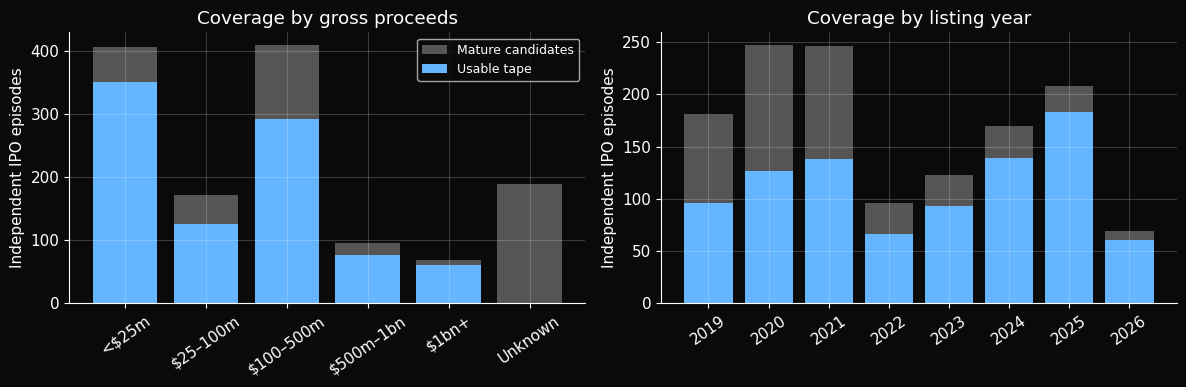

In [2]:
display(audit.groupby('exclusion_reason', dropna=False).size().rename('IPO episodes').to_frame())
fig = plots.coverage(audit)
plt.show()

# 3. Constructing the event-time return and volume panel

## 3.1 Initial IPO return and aftermarket returns

The IPO offer price and the first public-market close belong to a different stage of the listing process from subsequent close-to-close trading. The analysis therefore separates the **initial IPO return**

$$
IR_i
=
\log\left(\frac{P_{i,1}}{O_i}\right),
$$

from the aftermarket daily return

$$
r_{i,s}
=
\log\left(\frac{P_{i,s}}{P_{i,s-1}}\right),
\qquad s\ge2,
$$

where $O_i$ is the IPO offer price and $P_{i,1}$ is the first regular-market closing price.

This distinction matters because the offer price is determined before normal exchange trading begins. The main forecasting exercise starts from the first public-market close and studies the subsequent price-discovery process. For aftermarket bookkeeping, day 1 is therefore treated as the starting point and its aftermarket excess return is set to zero.

Early benchmark-adjusted performance through trading day $t$ is defined as

$$
\mathrm{EarlyCAR}_{i,t}
=
\sum_{s=2}^{t}
\left(r_{i,s}-r_{b,s}\right),
$$

where $r_{b,s}$ is the return of the selected market benchmark. Consequently,

$$
\mathrm{EarlyCAR}_{i,1}=0.
$$

The future outcome that the model attempts to predict is the remaining benchmark-adjusted log return through day 60,

$$
Y_{i,t}
=
\log\left(\frac{P_{i,60}}{P_{i,t}}\right)
-
\sum_{s=t+1}^{60}r_{b,s}.
$$

For example, $Y_{i,10}$ measures whether the IPO outperforms or underperforms the benchmark between the end of trading day 10 and trading day 60.

### Initial-return data boundary

The offer-to-first-close return is economically interesting, but it is not used as a predictor in the broad historical model because reliable reconstruction requires the offer price and historical first close to be expressed in consistent share units.

The public Yahoo split history does not contain every independently verified historical split event. For example, [Nasdaq confirms CPOP's October 2023 reverse split](https://www.nasdaqtrader.com/TraderNews.aspx?id=ECA2023-614), while the event was absent from the retrieved split response. A technically successful data request is therefore not sufficient evidence that the historical price units are correct.

Rather than introduce a potentially mismeasured initial-return predictor, the main aftermarket model excludes reconstructed first-day returns. Initial IPO returns are instead examined descriptively using the independently cached [IPO Scoop historical table](https://www.iposcoop.com/scoop-track-record-from-2000-to-present/). Observations are matched by ticker and IPO date and their offer prices are checked before the first-day return is calculated.

The resulting validation sample contains 218 matching IPOs and four observations whose offer-price definitions do not match.

,matched IPOs
offer_match,
False,4
True,218


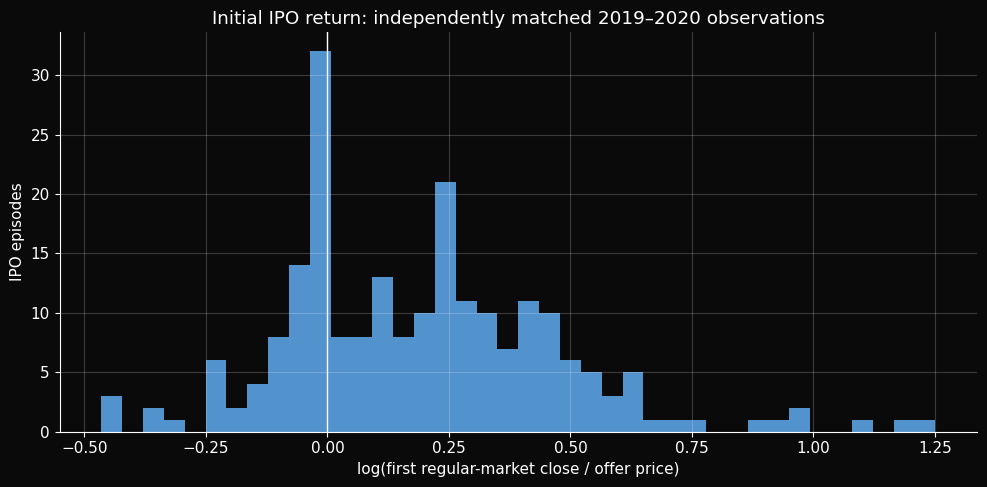

In [3]:
initial = pd.read_csv(OUT / 'tape_initial_return_validation.csv')
display(initial.groupby('offer_match').size().rename('matched IPOs').to_frame())
fig = plots.distribution_hist(initial.loc[initial.offer_match, 'initial_return_verified'],
    'Initial IPO return: independently matched 2019–2020 observations',
    'log(first regular-market close / offer price)', '02_initial_returns')
plt.show()

The histogram shows substantial variation in the offer-to-first-close return. Many IPOs close near or moderately above their offer price, some finish below it, and a small number experience very large positive first-day moves. The distribution illustrates the heterogeneity of IPO initial pricing outcomes.

However, this matched sample covers only the available 2019–2020 overlap and is therefore neither a complete estimate of the historical IPO initial-return distribution nor an input to the main predictive regressions.

**Finding.** Initial IPO returns can be studied independently for a limited validated subsample, but they cannot be reconstructed consistently enough across the broad public-data sample to enter the main model. Because $\mathrm{EarlyCAR}_{i,1}=0$, the day-1 price-only specification therefore contains no target-specific aftermarket price information and coincides with the historical reference-class forecast.

## 3.2 Benchmark-adjusted performance

The objective is to study the IPO's performance relative to the market rather than to forecast general market movements. The two candidate benchmarks are the **S&P 500 price index** and the **Nasdaq Composite price index**.

For each trading session, benchmark-adjusted return is defined as

$$
x_{i,s}
=
r_{i,s}-r_{b,s}.
$$

A positive value means that the IPO outperformed the benchmark during that session, while a negative value means that it underperformed. Benchmark log returns are calculated on each index's own valid trading calendar before they are aligned with IPO observations, while missing index prices are not interpolated.

## 3.3 Trading intensity

The observable trading-activity measure is cumulative dollar volume relative to the gross value of the IPO transaction:

$$
TI_{i,t}
=
\frac{
\sum_{s=1}^{t}P_{i,s}V_{i,s}
}{
\mathrm{GrossIPOProceeds}_i
}.
$$

The numerator

$$
P_{i,s}V_{i,s}
$$

is the dollar value of shares traded during session $s$. Dividing cumulative dollar volume by gross IPO offering value makes trading activity more comparable across transactions of very different sizes.

For example, if a \$5 billion IPO generates \$10 billion of cumulative dollar trading volume during its first five sessions, then

$$
TI_{i,5}=2
$$

This means that cumulative trading value was twice the gross value of the IPO transaction, but of course trading intensity should not be interpreted as **free float turnover**, since exact historical free float is not observed reliably enough for the full sample, and aggregate volume does not identify which investors traded or why. $TI$ is therefore used only as an observable measure of how intensively the newly listed security trades relative to the size of its offering.

A useful property of dollar volume is its invariance to a consistent stock-split rescaling. If historical price and volume are transformed by

$$
P'=\frac{P}{k},
\qquad
V'=kV,
$$

then

$$
P'V'=PV.
$$

The same constant rescaling also leaves aftermarket log returns unchanged. This makes dollar trading intensity and close-to-close log returns more robust to share-unit transformations than raw share-volume measures. And since trading intensity is strongly right-skewed, the regression uses

$$
\log(1+TI_{i,t}).
$$

This monotonic transformation preserves the ordering of IPOs while reducing the extent to which a small number of extremely active listings determine the scale of the predictor.

## 3.4 Realized uncertainty

I measured realized volatility is measured as

$$
RV_{i,t}
=
\sqrt{
\sum_{s=2}^{t}r_{i,s}^{2}
}.
$$

Unlike EarlyCAR, which measures the direction of relative price movement, $RV$ measures the magnitude of the IPO's early price fluctuations regardless of sign. A stock that alternates between large positive and negative returns can therefore have little cumulative return but high realized volatility.

I retained Drawdown and VIX information for diagnostics and for the reusable prediction interface, but they are not automatically included as additional fitted predictors.

## 3.5 Distribution of aftermarket outcomes

Before selecting a likelihood, I examined the distribution of aftermarket outcomes using only the initial learning cohort, defined as IPOs listed before 2022. Restricting this descriptive analysis to the earlier cohort prevents later validation observations from influencing the initial model design.

At the day-10 cutoff,

$$
Y_{i,10}
+
\mathrm{EarlyCAR}_{i,10}
$$

equals the cumulative benchmark-adjusted log return from the first public-market close through day 60. The following histogram therefore describes the distribution of complete aftermarket relative performance in the initial learning cohort.


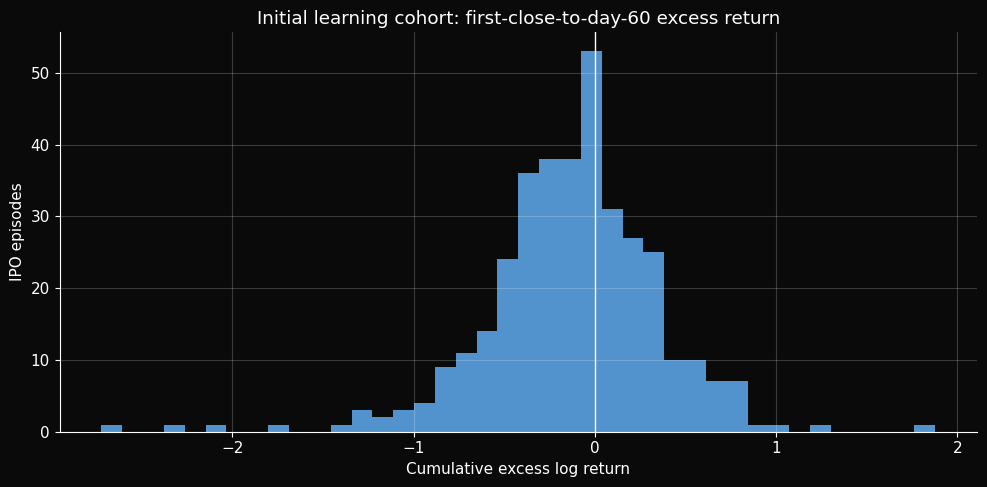

In [4]:
benchmark = selection['benchmark']
day10 = cutoff_data(audit, panel, 10, benchmark)
# Descriptive exploration restricted to the initial learning cohort.
explore = day10[day10.ipo_date < '2022-01-01']
fig = plots.distribution_hist(explore.y + explore.early_car,
    'Initial learning cohort: first-close-to-day-60 excess return',
    'Cumulative excess log return', '03_day60_returns')
plt.show()

A value near zero means that the IPO approximately matched the benchmark over the period. Negative observations represent relative underperformance, while positive observations represent relative outperformance.

The distribution is concentrated around relatively moderate outcomes but contains substantial observations in both tails. This is important for likelihood selection I had to made, since a Gaussian model assigns relatively little probability to extreme observations, while a Student-$t$ distribution is a better model capting heavier tails. The chart therefore motivates a formal comparison between Gaussian and Student-$t$ likelihoods. 
However, the evaluation of the Student-$t$ model will be done later using chronological out-of-sample predictive performance.
The overall outcome interpretation is a **benchmark-relative price return**.

**Finding.** The event-time panel provides three distinct pieces of observable information: early benchmark-relative price direction, trading activity relative to IPO deal size, and realized price uncertainty. The historical outcome distribution also contains material tail observations, motivating a later comparison of thin- and heavy-tailed predictive distributions rather than imposing one distributional assumption in advance.

# 4. Validating offered-share proxies

$$\widehat S_i=\mathrm{GrossIPOProceeds}_i/O_i,\quad
RE_i=(\widehat S_i-S_i^{SEC})/S_i^{SEC}.$$


,value
validated_IPOs,5.9000e+01
median_absolute_percentage_error,0.0000e+00
max_absolute_relative_error,8.3333e-10
rank_correlation,1.0000e+00
log_error_sd,1.3449e-10
log_actual_shares_sd,8.3502e-01


,relative error
0.0,0.0000e+00
0.1,0.0000e+00
0.5,0.0000e+00
0.9,0.0000e+00
1.0,8.3333e-10


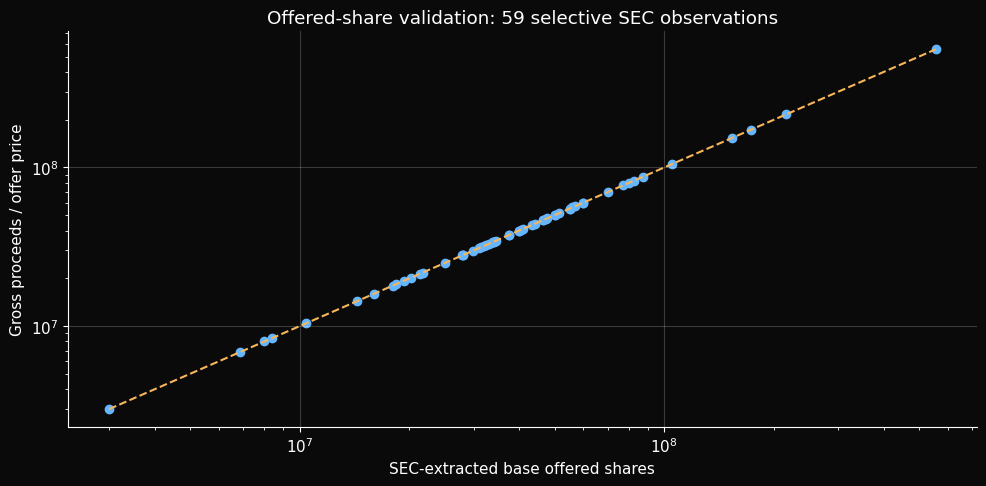

In [5]:
share_validation = pd.read_csv(OUT / 'tape_offered_share_validation.csv')
share_stats = pd.Series({
    'validated_IPOs': len(share_validation),
    'median_absolute_percentage_error': share_validation.relative_error.abs().median(),
    'max_absolute_relative_error': share_validation.relative_error.abs().max(),
    'rank_correlation': share_validation[['implied','ipo_shares_offered']].corr(method='spearman').iloc[0,1],
    'log_error_sd': share_validation.log_error.std(),
    'log_actual_shares_sd': share_validation.log_actual.std(),
})
display(share_stats.to_frame('value'))
display(share_validation.relative_error.quantile([0,.1,.5,.9,1]).to_frame('relative error'))
fig = plots.proxy(share_validation)
plt.show()

As showed in the chart, the 59 extractions agree almost exactly with the implied offered-share count, preserving ranks. 

# 5. Exploratory price-discovery evidence

Before implementing the true Bayesian approach, I look at the historical data distribution, asking two fundamental questions:

   1. If an IPO has already performed strongly or weakly during its first 10 days, does that seem related to how it performs from day 11 to day 60
   2. If an IPO has traded unusually heavily during its first 10 days (high TI), does that seem related to its remaining return from day 11 to day 60?

Again, I am consideing only IPOs listed before 2022.

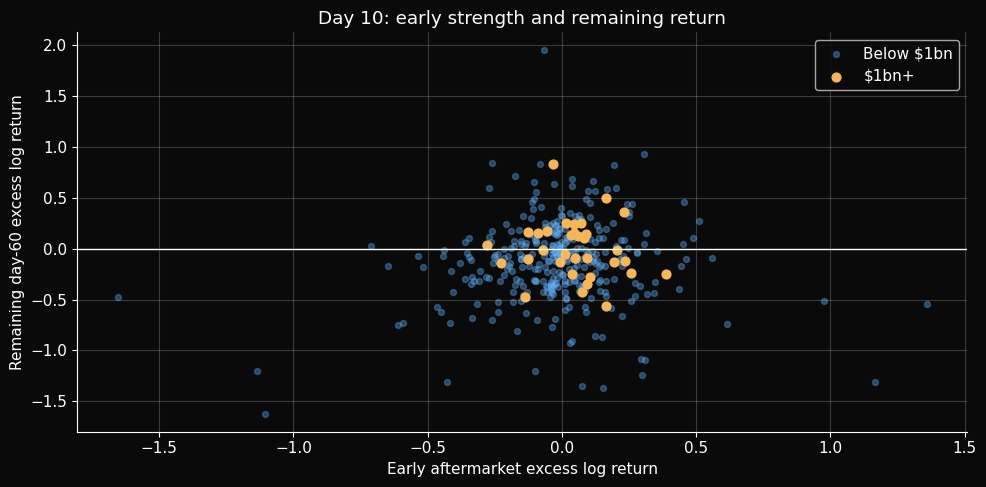

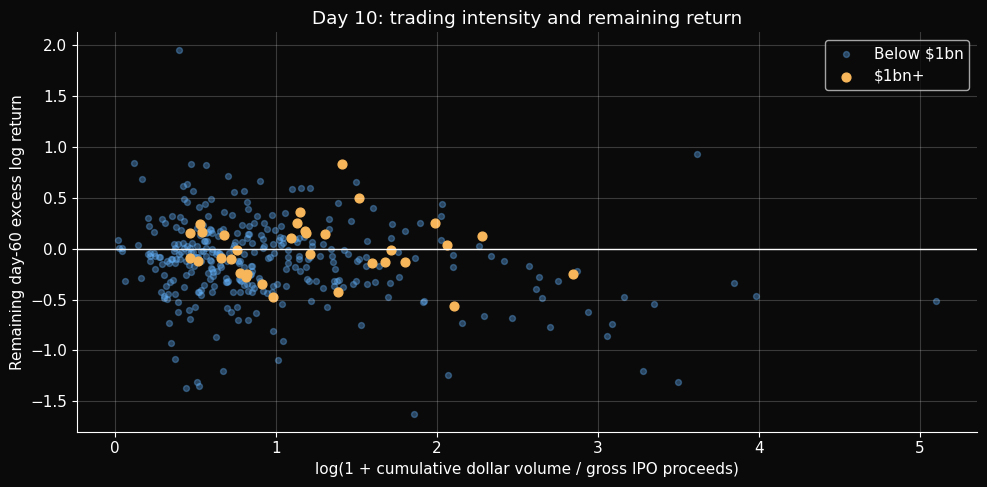

In [6]:
fig = plots.scatter(explore, 'early_car', 'Day 10: early strength and remaining return', '05_price_scatter')
plt.show()
fig = plots.scatter(explore, 'log_ti', 'Day 10: trading intensity and remaining return', '06_intensity_scatter')
plt.show()

The first chart shows a very dispersed point cloud, since around an early return near zero, future outcomes range from very negative to very positive and even among IPOs that have similar early returns, their outcomes can be very different. 

> Knowing only the first 10 days' relative return does not obviously determine what happen next.

The second chart shows the relationship of future returns with the $TI$ of the first trading days and the results are similar: I observe a lor of dispersion, with future outcomes that range from strongly negative to strongly positive for moderate trading intensity. It is also true that there are some very high-intensity IPOs that show negative future returns, suggesting a possible downward-sloping relationship. 

Basically, IPO outcomes still reman very uncertain even after observing the first 10 trading days and therefore a simple regression method would hide a large amount of uncertainty and this supports a research design that looks at probability distributions rather than point estimates. 




# 6. Bayesian research design
## 6.1 Prior, likelihood and posterior predictive distribution

The final goal is converting historical IPO evidence into a probability distribution for the future return of a new IPO given some varibales. For this reason I am using a Bayesian approach with prior, lieklihood and posterior predictor distribution.
 A prior describes plausible parameter values, a likelihood describes returns conditional on those parameters. Bayes' rule puts everything together:
$$p(\theta\mid D)\propto p(D\mid\theta)p(\theta),\qquad
p(Y_{new}\mid X_{new},D)=\int p(Y_{new}\mid X_{new},\theta)p(\theta\mid D)d\theta.$$
The last expression includes both parameter uncertainty and unpredictable variation across IPO outcomes.

- The prior says what parameter values are plausible before using the training observations to estimate them. Before seeing the historical relationship, the model developed does not assert that persistence or reversal must occur, but it places most prior probability around moderate coefficients
- The likelihood just asks how plausible the historical IPO outcomes that I observed would be if the assumed coefficients were true
- The posterior combines prior and likelihood, expressing uncertainty around the parameters after observing historical IPOs

Separate models are estimated at days 1, 5, 10 and 20. The common underlying model is: $$ Y_{i, t} \sim  t_{v_{t}}(\mu_{i, t}, \sigma_{i, t})$$
I modelled the remianing return of an IPO as coming from a Student-$t$ distribution, whose location depends on the observable characteristics of the IPO. The choice of the model is strictly related to the observed fatter tails of the IPO returns observed in the exploratory analysis.

I am going to modelled two questions: 

1. The center of the future return distribution $E[Y|X]$, represented by $\mu$, and this is where IPO size, early price performance and trading intensity enter
2.  The second is the dispersion of possible outcomes $\sigma_{i, t}$ and the realised volatility is allowed to tell that an IPO has a much wider range of possible future outcomes than another

## 6.2 Units and prior calibration

Within each training set, $z(X)=(X-\bar X_{train})/s_{X,train}$, so every predictor is standardised. This is important because, in this way, all predictors measure the change in the conditional location of future return associated with a one standard deviation change in predictor j. 

Since I want to give the prior a scale that is appropriate for the actual magnitude of IPO returns, I first measure how dispersed IPO outcomes actually are with the IRQ and then use this information to scale the priors: $s_Y$ is the training outcome IQR divided by 1.349, and it is used to calibrate how wide the Bayesian priors should be.

My regularizing priors are
$$\alpha\sim N(0,s_Y^2),\quad \beta_j\sim N(0,(s_Y/2)^2),\quad
\log\sigma\sim N(\log s_Y,0.5^2),$$
$$\delta_{RV}\sim N(0,0.35^2),\qquad\nu=2+\mathrm{Exponential}(\text{mean }10).$$
One standardized signal is therefore initially expected to shift the location by less than the typical cross-IPO return dispersion. These are **empirical-Bayes, training-data-calibrated priors**, not external knowledge. A half/double width sensitivity is reported. The Student-t scale is not its standard deviation: variance is $\sigma^2\nu/(\nu-2)$.

Before fitting the data, I simulate 500 prior predictive draws to verify that the assumed priors are quality priors that generates a sensible distribution. This helps me making sure that I am generating a distribution that is broad enough to permit a realistic IPO uncertainty, but not an obviously absurd one.

Moreover, I do not reported an expected price because the model uses a Student-$t$ for distribution of log-returns and, althought it has a finite mean and variance in this case, its tails decay only polynomially and converting log returns into gross returns requires exponentiation $e^Y$. In the positive tail, this produces a problem since exponential growth dominates polynomial decay and $E[e^Y]$ is not finite. For this reason, I do not report an arithmetic expected dollar price. However, quantiles, medians, predictive intervals and event probabilities remain well defined and are, therefore, the most appropriate summaries of the posterior predictive disribution.

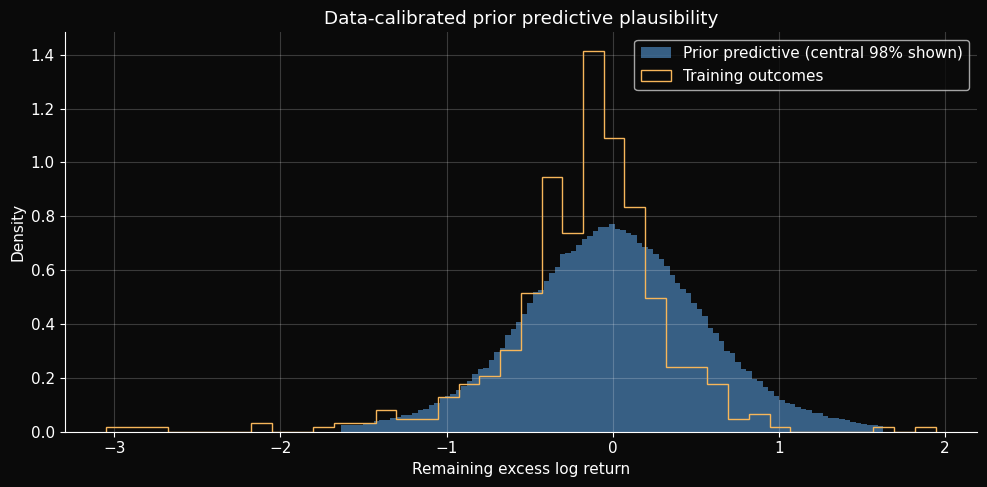

,kind,cutoff,prior_0.5%,prior_median,prior_99.5%
0,M0,1,-2.4729,0.0002,2.4623
1,M0,5,-2.1216,0.0002,2.1126
2,M0,10,-1.9893,0.0002,1.9808
3,M0,20,-1.7091,0.0002,1.7018
4,M1,5,-2.2211,0.0062,2.1970
5,M1,10,-2.0734,0.0052,2.0447
6,M1,20,-1.7713,0.0046,1.7521
7,M2,1,-2.5635,0.0114,2.5604
8,M2,5,-2.2713,-0.0004,2.2622
9,M2,10,-2.1224,0.0001,2.1052


In [7]:
prior_record = next(r for r in registry if r['phase']=='development' and r['kind']=='M0'
                    and r['cutoff']==10 and r['fold']=='2024')
prior_trace = load_trace(ROOT / prior_record['path'])
prior_training = day10[(day10.ipo_date < '2024-01-01') & (day10.outcome_date < '2024-01-01')]
fig = plots.prior_check(prior_trace, prior_training)
plt.show()
display(pd.DataFrame([{'kind':r['kind'], 'cutoff':r['cutoff'], 'prior_0.5%':r['prior_q'][0],
                       'prior_median':r['prior_q'][2], 'prior_99.5%':r['prior_q'][4]}
                      for r in registry if r['phase']=='development' and r['fold']=='2024']))

The prior predictive checks are critically used to verify that the Bayesian priors imply reasonable IPO return distribution before using historical outcomes to fit the model. The chart, in particular, compares the prior predictive distribution with the actual training outcomes for a representative case. The prior is broader than the observed data, but it is centered close to zero and it assigns meaningful probability to both large positive and negative outcomes.

The table basically shows the same diagnostic acorss different model and cutoffs dates: the prior predictive medians remain ~0, confirming that the priors do not impose persistence or reversal in advance. However, the predictive ranges become narrower at later cutoffs because there are fewer remaining trading days and $s_y$ used to calibrate the priors is smaller. More complex model (M2 and M3) are wider because they contain additional uncertain parameters.

# 7. M0 — historical reference class

Before answering if early price, trading intensity or realised volatility tell something useful about the remaining return of an IPO I need to understand what we could realistically predict without seeing these early signals. In other words, this means understanding what would I be able to predict using historical IPOs and knowing only the IPO size. It is the baseline model that all the other model will try to beat.

The model estimates an entire distribution, learning from historical IPOs thing like the baseline location of future returns, how IPO size relates to that location, the residual dispersion and the heaviness of the tails. Using held-out observation, I asked what distribution should describe the IPO remaining return, comparing $Y\sim N(\mu, \sigma^2)$ with $Y \sim t_{\nu}(\mu, \sigma)$ and concluding that the Student-$t$ performs much better in this case. Moroever, the model compares two benchmarks: a growth benchmark (Nasdaq Composite price index) and a broad benchmark (S&P 500 price index) in order to understand if the model's conclusion depend on whether IPO excess returns are measured relative to the broad US large cap market or a more growth and tech heavy benchmark.

Finally, I tested whether IPO size improves the historical reference distribution, to do so, I compared a baseline model containing only the intercept with a model that also includes continuous log IPO proceeds. The comparison was strictly made on the earlier chronological validation blocks, so that the IPOs used to evaluate the two specifications were not used to fit the models that actually predicted them.

The outcome is clear and shows that adding size produced a positive average improvement in log predictive density and the 95% IPO bootstrap interval is above zero. Basically, onditioning on IPO size allowed the model to assign, on average, more probability to returns that were later observed: $$ \mu_{i,t} = \alpha_t + \gamma_{t, z}(log Proceeds_i) $$

In [8]:
display(pd.Series(selection['benchmark_likelihood_scores'], name='held-out log score').to_frame())
display(pd.DataFrame(selection['size_gate']).T)

,held-out log score
"('growth', 'student')",-1.2048
"('broad', 'student')",-1.2116
"('growth', 'gaussian')",-1.6516
"('broad', 'gaussian')",-1.6517


,delta,lo,hi,n
1,0.1254,0.0698,0.1775,298.0
5,0.0704,0.0243,0.1141,298.0
10,0.0477,0.0090,0.0877,298.0
20,0.0472,0.0100,0.0845,298.0


**Finding.** The Student-t screen materially improves on Gaussian, while the difference between broad and growth benchmarks is much smaller. Continuous size improves the reference distribution. We therefore compare all tape signals against a size-conditioned baseline, rather than allowing intensity to stand in for deal size. Benchmark choice changes the definition of excess return; neither index is asserted to be the unique correct risk model.

# 8. M1 — early price information

In the second version of the model I tested whether the early price path of the IPO itself improved the forecast with respect to M0. The new variable is the cumulative benchmark-adjusted aftermarket return, defined as follows:
$$
\mathrm{EarlyCAR}_{i,t}
=
\sum_{s=2}^{t}
(r_{i,s}-r_{b,s}),
$$
which measures whether the IPO has outperformed or underperformed its benchmark from the first public-market close up to day $t$. The return starts from Day 2 because the offer-to-first-close return cannot be reconstructed consisently across the full historical sample due to later stock splits or reverse splits that left the offer price and historical closing price expressed in different share units. For this reason, the main model focuses only on close-to-close aftermarket returns, for which common multiplicative price adjustment cancel out.

M1 adds this early price signal to the common size-controlled baseline:
$$
\mu_{i,t}
=
\alpha_t
+
\gamma_t z(\log \mathrm{Proceeds}_i)
+
\beta_{P,t} z(\mathrm{EarlyCAR}_{i,t}).
$$

The coefficient $\beta_{P,t}$ threfore measures whether, conditional on IPO size, stronger early benchmark-adjusted performance is associated with stronger or weaker returns. A positive coefficient is related to conditional persistence, while a negative coefficient corresponds to reversal. Since EarlyCAR is standardised as a measure, $\beta_{P,t}$ can be interpreted as the change in the location of the remaining-return distribution associated with a one standard deviation increase in early price performance. At Day 1, however, $\mathrm{EarlyCAR}_{i,1}=0$, so M1 and M0 are identical and no price information test is actually possible.

The reuslts are clear and the historical posterior points towards persistence, rather than reversal. At day 10, for example, the posterior median of the early price coefficient is about $0.038$, with a 95% credible interval of approximately $[0.001, 0074]$ and posterior probability $P(\beta_{P,10}>0)\approx97.8\%$. Separately, I tested wheter this positive association improves forecasting on held-out development IPOs and, relative to M0, M1 improves average log predictive density by about $0.014$ nats per IPO at day 10, with a 95% IPO-bootstrap interval of $[0.002, 0.027]$. The interval is above zero, so the model judged early price performance to contain incremental predictive information beyond IPO size at this horizon. The two results answer different questions: the posterior coefficient describes he direction and the magnitude of the conditional association, while the held-out log-score comparison shows whether adding the price signal actually improves the quality of the predicted probability distribution.

In [9]:
display(coefficients.query("phase == 'final' and kind == 'M1' and coefficient == 'early_car'")
        [['cutoff','median','lo','hi','p_positive','p_negative']])
price_comparisons = {k:v for k,v in selection['comparisons'].items() if 'M1-M0' in k}
display(pd.DataFrame(price_comparisons).T)

,cutoff,median,lo,hi,p_positive,p_negative
84,5,0.0583,0.0120,0.0997,0.9922,0.0078
94,10,0.0375,0.0009,0.0739,0.9781,0.0219
104,20,0.0355,0.0024,0.0679,0.9809,0.0191


,delta,lo,hi,n,crps_delta
1:M1-M0,0.0000,0.0000,0.0000,298.0,0.0000
5:M1-M0,0.0073,-0.0057,0.0215,298.0,0.0016
10:M1-M0,0.0137,0.0015,0.0271,298.0,0.0002
20:M1-M0,0.0152,0.0034,0.0282,298.0,-0.0010


**Finding.** At day 10, the frozen historical price coefficient has median **+0.038**, 95% credible interval **[+0.001, +0.074]**, and posterior probability of a positive sign **97.8%**. Its development log-score contribution is +0.014 nats per IPO (95% IPO-bootstrap interval +0.002 to +0.027). Posterior direction and predictive contribution answer different questions; final-cohort confirmation appears in Section 11.

# 9. M2 — price plus trading intensity

After testing whether the early price path contains information beyond IPO size, I tested whether the amount of early trading activity adds further predictive information once both size and price performance are already known. Trading intensity is measured as cumulative dollar trading relative to the gross value of the IPO transaction:

$$
TI_{i,t}
=
\frac{
\sum_{s=1}^{t}P_{i,s}V_{i,s}
}{
\mathrm{GrossIPOProceeds}_i
}.
$$
This measure makes trading activity more comparable across IPOs of different sizes, but it should not be interpreted as free-float turnover because historical free float is not observed consistently. Since trading intensity is strongly right-skewed, the model uses $\log(1+TI)$ and then standardises it using the training sample.

M2 adds trading intensity to the information already contained in M1:
$$
\mu_{i,t}
=
\alpha_t
+
\gamma_t z(\log \mathrm{Proceeds}_i)
+
\beta_{P,t}z(\mathrm{EarlyCAR}_{i,t})
+
\beta_{TI,t}z(\log(1+TI_{i,t})).
$$
The coefficient $\beta_{TI,t}$ therefore measures how the location of the remaining-return distribution changes when trading intensity increases by one training-sample standard deviation, conditional on IPO size and early price performance. At day 10, the historical posterior median of this coefficient is approximately $-0.105$, with a 95% credible interval of $[-0.140,-0.072]$, indicating a negative conditional association between unusually intense trading and the location of subsequent returns. This should not be interpreted as evidence of selling pressure or investor demand, since aggregate volume does not identify who traded or why.

Separately, I tested whether adding trading intensity actually improves the probability forecast on held-out development IPOs. At day 10, M2 improves average log predictive density relative to M1 by approximately $0.038$ nats per IPO, with a 95% IPO-bootstrap interval of $[0.008,0.072]$. The corresponding CRPS also improves. Since M2 differs from M1 only through the trading-intensity variable, this development result suggests that trading activity contains incremental predictive information beyond size and early price performance. As in the previous section, the posterior coefficient describes the direction of the conditional association, while the held-out score comparison determines whether the additional variable improves prediction. Final-cohort validation is considered separately.

In [10]:
display(coefficients.query("phase == 'final' and kind == 'M2' and coefficient == 'log_ti'")
        [['cutoff','median','lo','hi','p_positive','p_negative']])
display(pd.DataFrame({k:v for k,v in selection['comparisons'].items() if 'M2-M1' in k}).T)

,cutoff,median,lo,hi,p_positive,p_negative
81,1,-0.1862,-0.2291,-0.1426,0.0,1.0
87,5,-0.1443,-0.1847,-0.1061,0.0,1.0
97,10,-0.1054,-0.1398,-0.0716,0.0,1.0
107,20,-0.0713,-0.0996,-0.0419,0.0,1.0


,delta,lo,hi,n,crps_delta
1:M2-M1,0.0888,0.0474,0.1359,298.0,-0.0337
5:M2-M1,0.0697,0.0362,0.1093,298.0,-0.0228
10:M2-M1,0.0383,0.0075,0.0716,298.0,-0.0155
20:M2-M1,0.0256,0.0047,0.0486,298.0,-0.0070


**Finding.** The day-10 development increment from trading intensity is +0.038 nats per IPO (95% IPO-bootstrap interval +0.008 to +0.072). This comparison, its CRPS counterpart and final validation determine whether volume is signal for this forecasting problem. Descriptively high activity alone cannot establish investor demand or persistence.

# 10. M3 — conditional uncertainty

M3 retains M2's mean and models the scale:
$$\log\sigma_{i,t}=\delta_{0,t}+\delta_{RV,t}z(RV_{i,t}).$$
The hypothesis concerns uncertainty, not a directional effect of volatility. At day 1, RV is zero and M3 equals M2. A wider conditional interval can be informative if it improves calibration and proper predictive scores.

,delta,lo,hi,n,crps_delta
1:M3-M2,0.0000,0.0000,0.0000,298.0,0.0000
5:M3-M2,0.0426,0.0126,0.0742,298.0,-0.0054
10:M3-M2,0.0577,0.0149,0.0994,298.0,-0.0029
20:M3-M2,0.0435,0.0105,0.0773,298.0,-0.0024


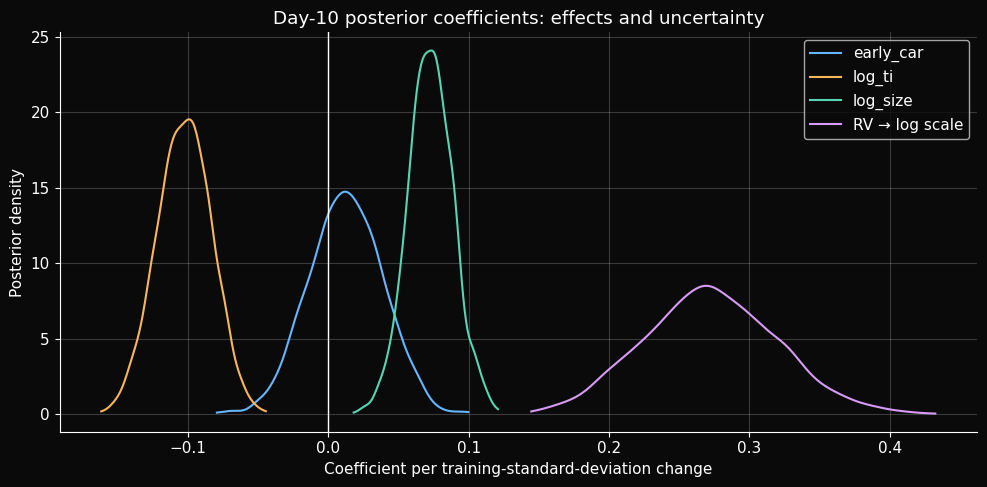

In [11]:
display(pd.DataFrame({k:v for k,v in selection['comparisons'].items() if 'M3-M2' in k}).T)
record_m3 = next(r for r in registry if r['phase']=='final' and r['kind']=='M3' and r['cutoff']==10)
trace_m3 = load_trace(ROOT / record_m3['path'])
fig = plots.coefficient_density(trace_m3)
plt.show()

**Finding.** The day-10 development scale-model increment is +0.058 nats per IPO (95% IPO-bootstrap interval +0.015 to +0.099). Selection also requires nonworsening CRPS; a log-score gain alone does not automatically promote this model. The RV coefficient describes conditional dispersion, never a causal volatility effect.

# 11. Chronological out-of-sample model comparison

The models selected during the development stage are finally evaluated on the untouched 2025–2026 cohort of 244 IPOs. 
At this point the modelling choices are completely chosen: the final cohort is not used to choose predictors, priors or models, so it provides the closest test of how the procedure would behave on genuinely new IPOs. 

The selected model differs by cutoff because each cutoff represents a different forecasting problem: at day 1 only one session of trading has been observed, while at days 5, 10 and 20 progressively more information is available but fewer days remain until the day-60 target. The final results are weaker than the development evidence, some richer models still obtain better average predictive scores, especially M3, but several incremental improvements have bootstrap intervals crossing zero. For example, at day 10 the additional contribution of trading intensity does not replicate clearly, while the improvement from allowing realised volatility to change the predictive scale is positive but uncertain. 

The main limitation is calibration: nominal 80% predictive intervals contain only about 65–72% of realised outcomes in the broad final cohort, while nominal 95% intervals cover only about 86–89%. The model therefore contains some predictive information, but its distributions are systematically too narrow.

,frozen selected model
1,M2
5,M3
10,M3
20,M3


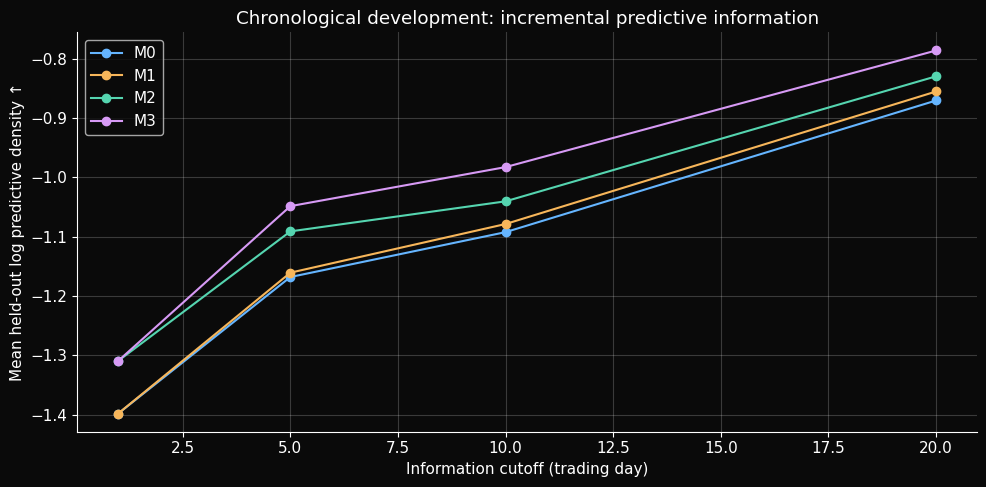

,kind,cutoff,n,log_score,crps,coverage50,coverage80,coverage95,mae,rmse
17,M0,1,244,-1.2243,0.4451,0.3934,0.6680,0.8893,0.5837,0.8158
18,M0,5,244,-1.1180,0.4053,0.4098,0.6844,0.8730,0.5260,0.7524
19,M0,10,244,-1.0501,0.3812,0.3770,0.6721,0.8730,0.4939,0.7170
20,M0,20,244,-0.8433,0.3156,0.3893,0.7049,0.8934,0.4119,0.6066
21,M1,5,244,-1.1144,0.4046,0.4098,0.6803,0.8811,0.5245,0.7526
22,M1,10,244,-1.0394,0.3805,0.3893,0.6721,0.8770,0.4916,0.7204
23,M1,20,244,-0.8338,0.3143,0.4057,0.7131,0.8975,0.4099,0.6070
24,M2,1,244,-1.2537,0.4540,0.3852,0.6516,0.8730,0.5885,0.8320
25,M2,5,244,-1.1439,0.4108,0.3934,0.6639,0.8484,0.5309,0.7592
26,M2,10,244,-1.0411,0.3782,0.3893,0.6721,0.8607,0.4879,0.7103


In [12]:
display(pd.Series(selection['selected_by_cutoff'], name='frozen selected model').to_frame())
fig = plots.scores(scores, benchmark, selection['likelihood'])
plt.show()
display(scores.query("phase == 'final'")
        [['kind','cutoff','n','log_score','crps','coverage50','coverage80','coverage95','mae','rmse']])

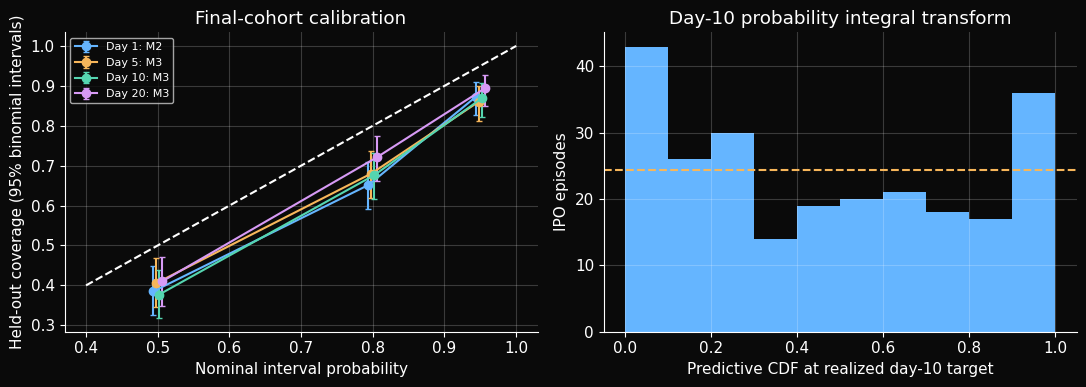

,phase,threshold,cutoff,comparison,delta,lo,hi,n
36,final,0.0,5,M1-M0,0.0036,-0.0119,0.0193,244
37,final,0.0,5,M2-M1,-0.0295,-0.0749,0.0151,244
38,final,0.0,5,M3-M2,0.0319,0.0028,0.0627,244
39,final,0.0,10,M1-M0,0.0107,-0.0021,0.0244,244
40,final,0.0,10,M2-M1,-0.0017,-0.0392,0.0361,244
41,final,0.0,10,M3-M2,0.0321,-0.0020,0.0695,244
42,final,0.0,20,M1-M0,0.0095,-0.0051,0.0239,244
43,final,0.0,20,M2-M1,-0.0073,-0.0348,0.0199,244
44,final,0.0,20,M3-M2,0.0284,0.0024,0.0562,244


In [13]:
fig = plots.calibration(scores, selection)
plt.show()
size_contrasts = pd.read_csv(OUT / 'tape_size_contrasts.csv')
display(size_contrasts.query("phase == 'final' and threshold == 0"))

The score tables compare the models on the final cohort using log predictive density, where higher values are better, and CRPS, where lower values are better. The pairwise comparisons such as $(M1-M0)$, $(M2-M1)$, and $(M3-M2)$ isolate the incremental contribution of early price, trading intensity and conditional volatility respectively; a bootstrap interval crossing zero means that the final sample does not clearly establish an improvement from that additional component. 

The calibration chart then checks a different property: whether the probability intervals mean what they claim. Each of the 244 IPOs receives its own predictive distribution and, for example, its own 80% interval. The empirical coverage is the fraction of realised returns that actually fall inside those intervals. A perfectly calibrated model would lie on the 45-degree line, while the observed points below that line show undercoverage and therefore excessive confidence. The error bars are Jeffreys binomial intervals, which quantify uncertainty around the observed coverage rate because only a finite number of IPOs is available. 

The PIT histogram provides the same calibration check from another angle: a calibrated model should produce an approximately uniform histogram, while the observed excess of outcomes near 0 and 1 indicates that realised returns fall in the predicted tails too often. Together, the tables and charts show that some relative predictive improvements survive, but the uncertainty produced by the model is not yet sufficiently calibrated.

# 12. Sequential forecasting for a live IPO

The following step is to illustrate how the framework can be used sequentially as a new IPO starts trading. Instead of estimating new population parameters every day, the historical Bayesian models remain frozen and the forecast is updated only by conditioning on the new information obsereved for the IPO. Before trading, in fact, the reference forecast uses historical IPO outcomes and offering size. After the first session, trading intensity becomes available, while at later cutoffs the model can also use early benchmark-adjusted price performance and realised volatility. The target changes at each cutoff: at day 5 the model predicts the benchmark-adjusted return from day 6 to day 60, while at day 20 it predicts only the return from day 21 to day 60. The different cutoffs should therefore be interpreted as separate conditional forecasts rather than as a single recursively updated latent return.

The figure illustrates this process for Medline (MDLN). The left panel shows the predictive distribution at the pre-trading reference point and after days 1, 5, 10 and 20. The central line is the predictive median, while the shaded regions represent the 50%, 80% and 95% predictive intervals. As new MDLN trading information becomes available, the median forecast moves from a relatively positive initial value toward a more neutral remaining-return forecast, while substantial uncertainty remains around it. The orange line reports the return that MDLN actually realised from each cutoff until day 60. Because the target horizon changes at every cutoff, a relatively flat realised-return line does not imply flat daily returns; it means that the benchmark-adjusted returns accumulated between successive cutoffs were relatively small or offset one another.

The right panel summarises the same predictive distributions using two event probabilities. The first is
$$
P(Y_{i,t}>0)
$$
the probability that MDLN outperforms its benchmark over the remaining horizon. The second is
$$
P(Y_{i,t}<\log(0.8))
$$
the probability of a benchmark-relative wealth loss greater than 20%. The threshold is written as $\log(0.8)$ because the model works with log returns: a 20% loss leaves 80% of starting relative wealth, and the corresponding log return is $\log(0.8)\approx-0.223$. For MDLN, the probability of positive remaining performance decreases as additional tape information is observed, while the probability of a large relative loss changes less substantially.



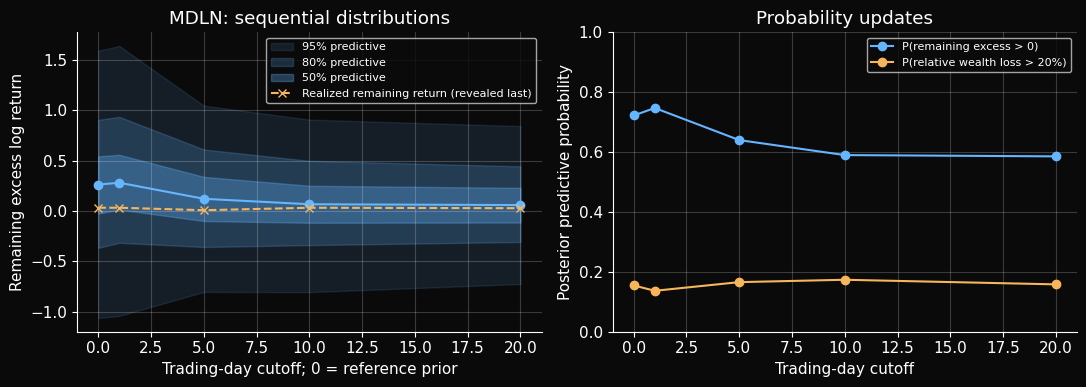

,ticker,cutoff,model,median_log,lo50,hi50,lo80,hi80,lo95,hi95,p_positive,p_loss20
0,ELOG,0,M0,-0.4931,-0.7796,-0.2083,-1.1257,0.1666,-1.8243,0.7989,0.1466,0.7364
1,ELOG,1,M2,-0.4044,-0.6709,-0.1267,-1.0095,0.2347,-1.7390,0.9044,0.1765,0.6754
2,ELOG,5,M3,-0.2746,-0.5407,-0.0088,-0.8483,0.3236,-1.4116,0.8689,0.2465,0.5576
3,ELOG,10,M3,-0.2064,-0.4452,0.0331,-0.7334,0.3487,-1.3088,0.8628,0.2835,0.4858
4,ELOG,20,M3,-0.1675,-0.3624,0.0319,-0.6006,0.2887,-1.0860,0.7704,0.2861,0.4262
5,POM,0,M0,-0.3699,-0.6545,-0.0881,-1.0020,0.2906,-1.7016,0.9260,0.2027,0.6397
6,POM,1,M2,-0.4971,-0.7611,-0.2244,-1.0926,0.1478,-1.8045,0.8203,0.1373,0.7458
7,POM,5,M3,-0.3782,-0.6112,-0.1345,-0.9058,0.1637,-1.4232,0.6632,0.1634,0.6703
8,POM,10,M3,-0.3165,-0.5196,-0.1048,-0.7877,0.1740,-1.2950,0.6295,0.1768,0.6165
9,POM,20,M3,-0.2549,-0.4424,-0.0689,-0.6612,0.1571,-1.1035,0.6064,0.1881,0.5518


In [14]:
population = load_frozen_population()
pseudo = pd.read_csv(OUT / 'tape_pseudo_live.csv')
fig = plots.sequential(pseudo)
plt.show()
display(pseudo[['ticker','cutoff','model','median_log','lo50','hi50','lo80','hi80','lo95','hi95','p_positive','p_loss20']])